In [425]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler,RobustScaler


### Load Dataset

In [426]:
df=pd.read_csv('standardscaler_.csv')
df

,Experience_Years,Age,Education_Level,Hours_Per_Week,Salary
0,5.99,34.63,3,41.12,87638.54
1,4.72,39.55,4,46.82,84956.80
2,6.30,23.01,1,40.63,73501.52
3,8.05,32.81,4,37.85,100707.27
4,4.53,26.75,3,40.61,80094.46
...,...,...,...,...,...
495,6.08,28.59,4,33.27,67897.46
496,2.93,38.99,4,40.63,76200.98
497,4.62,33.20,4,49.69,72773.89
498,3.25,27.14,4,35.00,76373.15


In [427]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience_Years  500 non-null    float64
 1   Age               500 non-null    float64
 2   Education_Level   500 non-null    int64  
 3   Hours_Per_Week    500 non-null    float64
 4   Salary            500 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 19.7 KB


In [428]:
df.corr()

,Experience_Years,Age,Education_Level,Hours_Per_Week,Salary
Experience_Years,1.000000,-0.073255,-0.071472,0.060724,0.514034
Age,-0.073255,1.000000,-0.004516,0.047329,-0.010178
Education_Level,-0.071472,-0.004516,1.000000,0.006592,0.323822
Hours_Per_Week,0.060724,0.047329,0.006592,1.000000,0.083765
Salary,0.514034,-0.010178,0.323822,0.083765,1.000000


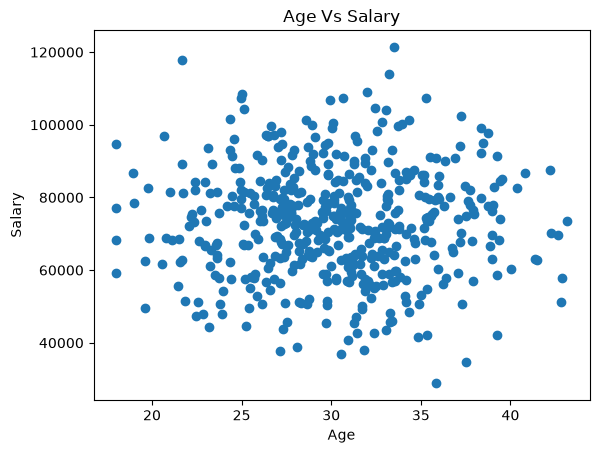

In [429]:
plt.scatter(df['Age'],df['Salary'])
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Age Vs Salary')
plt.show()

### Defining x and y

In [430]:
x=df.drop(columns='Salary')
y=df['Salary']

<Axes: >

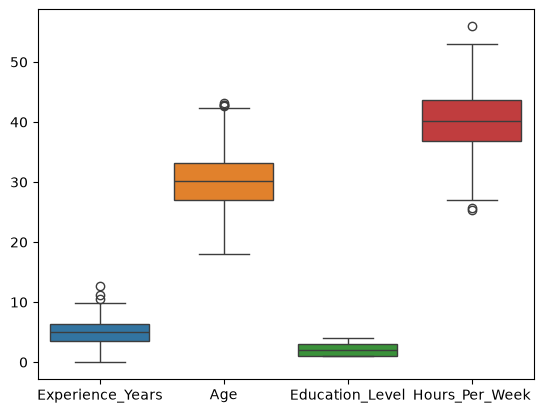

In [431]:
sns.boxplot(x)


### Train_test_split

In [432]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

### Linear Regression

In [433]:
model= LinearRegression()

model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[4202.96, 144.39,4927.27, 142.9 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Experience_Years','Age','Education_Level','Hours_Per_Week']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.964e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [434]:
# Train Data

ytrain_predicted= model.predict(xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.4049766661502865
11705.764728765964
9067.487383522943


In [435]:
# Test Data

ytest_predicted =model.predict(xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))


0.36362143647183776
11226.126639608387
9188.536737319992


### Polynomial Regression

In [436]:
Poly_model = PolynomialFeatures()

updated_xtrain = Poly_model.fit_transform(xtrain)
updated_xtest = Poly_model.transform(xtest)


In [437]:
model=LinearRegression()

model.fit(updated_xtrain,ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0. ,4115.4 , -12.83,...,-205.44,-136. , 23.84]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.388e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[8980.64,6606.09,2017.97,..., 3.27, 1.82, 0. ]"


In [438]:
# Train Data

ytrain_predicted=model.predict(updated_xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.4171496560890041
11585.407688881865
9019.831179353065


In [439]:
# Train Data

ytest_predicted = model.predict(updated_xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))

0.2860694593826636
11890.50079933002
9843.598450529105


### StandardScaler Preprocessing Technique

In [440]:
scaling = StandardScaler()

xtrain_scaled= scaling.fit_transform(xtrain)
xtest_scaled = scaling.transform(xtest)

In [441]:
Poly=PolynomialFeatures(degree=2)

updated_xtrain = Poly.fit_transform(xtrain_scaled)
updated_xtest = Poly.transform(xtest_scaled)

model = LinearRegression()
model.fit(updated_xtrain,ytrain)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0. ,8300.11, 810.51,...,-253.69,-753.72, 593.11]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.379e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[28.91,27.67,27.13,...,17.37,15.77, 0. ]"


In [442]:
# Train Data

ytrain_predicted = model.predict(updated_xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.4171496560890041
11585.407688881865
9019.831179353012


In [443]:
# Test Data

ytest_predicted = model.predict(updated_xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))

0.28606945938265393
11890.5007993301
9843.59845052923


### RobustScaler Preprocessing Technique

In [444]:
robust_scaling = RobustScaler()

xtrain_scaled = robust_scaling.fit_transform(xtrain)
xtest_scaled = robust_scaling.transform(xtest)

In [445]:
Poly = PolynomialFeatures(degree=2)

updated_xtrain = Poly.fit_transform(xtrain_scaled)
updated_xtest = Poly.transform(xtest_scaled)

model = LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ 0. ,11645.69, 1055.22,..., -821.76,-1879.45, 1138.51]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.387e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[16. ,15.54,14.97,..., 7.37, 4.94, 0. ]"


In [446]:
# Train Data

ytrain_predicted = model.predict(updated_xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))

0.4171496560890041
11585.407688881865
9019.831179353012


In [447]:
# Test Data

ytest_predicted = model.predict(updated_xtest)

print(r2_score(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))

0.28606945938265393
11890.5007993301
9843.59845052923
